# Packages

In [41]:
pip install pgmpy

In [42]:
pip install xgboost

In [43]:
import pandas as pd
import numpy as np
import os

import ipywidgets
import networkx as nx
import matplotlib.pyplot as plt
import time

import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler, OrdinalEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from xgboost import XGBClassifier
from sklearn.metrics import roc_curve, auc, classification_report, confusion_matrix, roc_auc_score

from sklearn.metrics import (
    roc_auc_score,
    brier_score_loss,
    log_loss,
    precision_score,
    recall_score,
    f1_score
)

from sklearn.feature_selection import mutual_info_classif


from pgmpy.models import DiscreteBayesianNetwork, LinearGaussianBayesianNetwork
from pgmpy.estimators import BayesianEstimator, K2, HillClimbSearch, BDeu, BIC, TreeSearch
from pgmpy.inference import VariableElimination

# Data load

In [44]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [45]:
work_dir = "/content/drive/MyDrive/Thesis/Notebooks/"
os.chdir(work_dir)

In [46]:
print("Contents of My Drive:")
print(os.listdir(work_dir))

print(f"\n‘work’ directory is ready at:\n{work_dir}")

Contents of My Drive:
['HMEQ_Bayesian.ipynb', 'Test.ipynb', 'Data', '.ipynb_checkpoints', 'HMEQ_BayesianSimple.ipynb', 'requirements.txt', 'LC_ML.ipynb', 'Taiwan_ML.ipynb', 'We_ML.ipynb', 'German_ML.ipynb', 'Japan_ML.ipynb', 'HMEQ_ML.ipynb']

‘work’ directory is ready at:
/content/drive/MyDrive/Thesis/Notebooks/


In [47]:
df = pd.read_csv("Data/hmeq.csv")

In [48]:
df

,BAD,LOAN,MORTDUE,VALUE,REASON,JOB,YOJ,DEROG,DELINQ,CLAGE,NINQ,CLNO,DEBTINC
0,1,1100,25860.0,39025.0,HomeImp,Other,10.5,0.0,0.0,94.366667,1.0,9.0,NaN
1,1,1300,70053.0,68400.0,HomeImp,Other,7.0,0.0,2.0,121.833333,0.0,14.0,NaN
2,1,1500,13500.0,16700.0,HomeImp,Other,4.0,0.0,0.0,149.466667,1.0,10.0,NaN
3,1,1500,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,0,1700,97800.0,112000.0,HomeImp,Office,3.0,0.0,0.0,93.333333,0.0,14.0,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...
5955,0,88900,57264.0,90185.0,DebtCon,Other,16.0,0.0,0.0,221.808718,0.0,16.0,36.112347
5956,0,89000,54576.0,92937.0,DebtCon,Other,16.0,0.0,0.0,208.692070,0.0,15.0,35.859971
5957,0,89200,54045.0,92924.0,DebtCon,Other,15.0,0.0,0.0,212.279697,0.0,15.0,35.556590
5958,0,89800,50370.0,91861.0,DebtCon,Other,14.0,0.0,0.0,213.892709,0.0,16.0,34.340882


In [49]:
df.describe()

,BAD,LOAN,MORTDUE,VALUE,YOJ,DEROG,DELINQ,CLAGE,NINQ,CLNO,DEBTINC
count,5960.000000,5960.000000,5442.000000,5848.000000,5445.000000,5252.000000,5380.000000,5652.000000,5450.000000,5738.000000,4693.000000
mean,0.199497,18607.969799,73760.817200,101776.048741,8.922268,0.254570,0.449442,179.766275,1.186055,21.296096,33.779915
std,0.399656,11207.480417,44457.609458,57385.775334,7.573982,0.846047,1.127266,85.810092,1.728675,10.138933,8.601746
min,0.000000,1100.000000,2063.000000,8000.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.524499
25%,0.000000,11100.000000,46276.000000,66075.500000,3.000000,0.000000,0.000000,115.116702,0.000000,15.000000,29.140031
50%,0.000000,16300.000000,65019.000000,89235.500000,7.000000,0.000000,0.000000,173.466667,1.000000,20.000000,34.818262
75%,0.000000,23300.000000,91488.000000,119824.250000,13.000000,0.000000,0.000000,231.562278,2.000000,26.000000,39.003141
max,1.000000,89900.000000,399550.000000,855909.000000,41.000000,10.000000,15.000000,1168.233561,17.000000,71.000000,203.312149


In [50]:
for col in df.columns:
    amount_null = df[col].isnull().sum()
    ratio = (amount_null / df.shape[0]) * 100.0

    print(f" {col} has {amount_null} null values. Which accounts for{ratio: .2f}%")


 BAD has 0 null values. Which accounts for 0.00%
 LOAN has 0 null values. Which accounts for 0.00%
 MORTDUE has 518 null values. Which accounts for 8.69%
 VALUE has 112 null values. Which accounts for 1.88%
 REASON has 252 null values. Which accounts for 4.23%
 JOB has 279 null values. Which accounts for 4.68%
 YOJ has 515 null values. Which accounts for 8.64%
 DEROG has 708 null values. Which accounts for 11.88%
 DELINQ has 580 null values. Which accounts for 9.73%
 CLAGE has 308 null values. Which accounts for 5.17%
 NINQ has 510 null values. Which accounts for 8.56%
 CLNO has 222 null values. Which accounts for 3.72%
 DEBTINC has 1267 null values. Which accounts for 21.26%


In [51]:
df[df['BAD'	]==1].shape[0]

1189

In [52]:
df.dtypes

,0
BAD,int64
LOAN,int64
MORTDUE,float64
VALUE,float64
REASON,object
JOB,object
YOJ,float64
DEROG,float64
DELINQ,float64
CLAGE,float64


In [53]:
num_cols = df.select_dtypes(include=np.number).columns
cat_cols = df.select_dtypes(exclude=np.number).columns

In [54]:
len(num_cols)

11

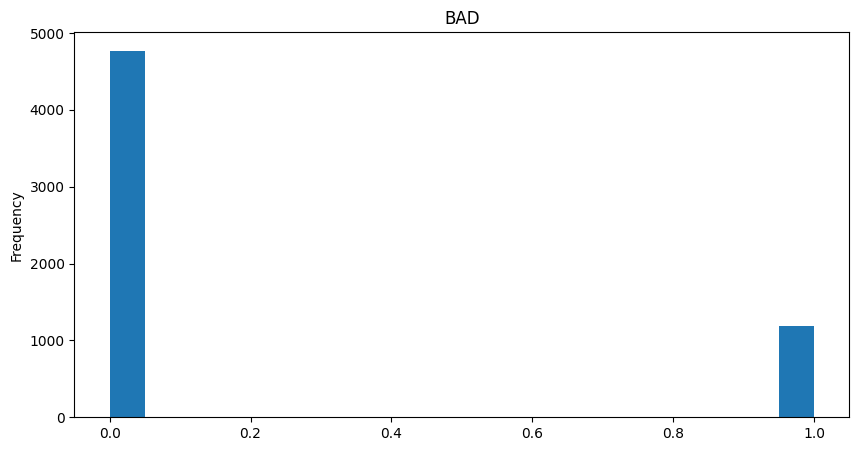

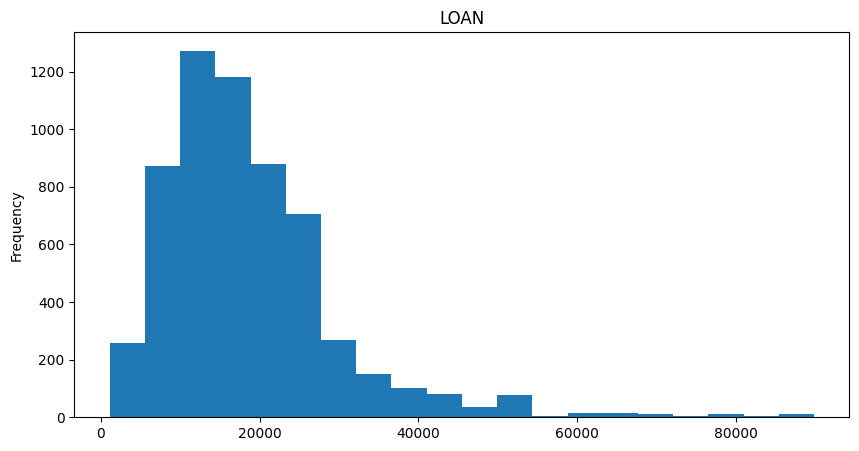

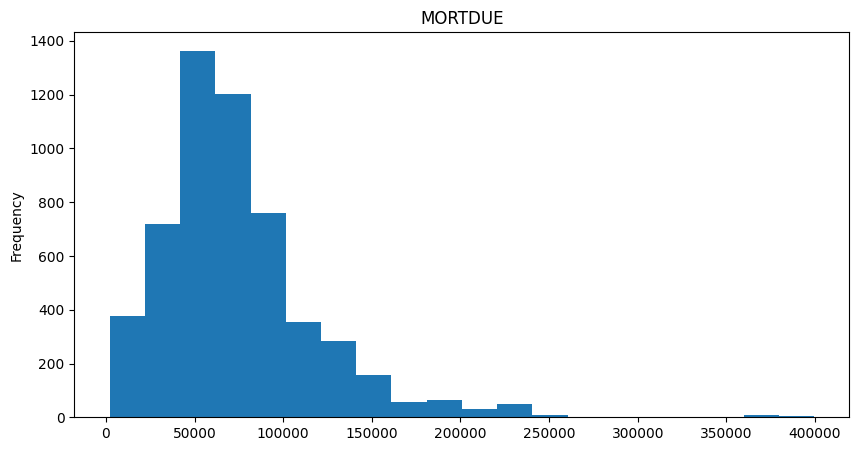

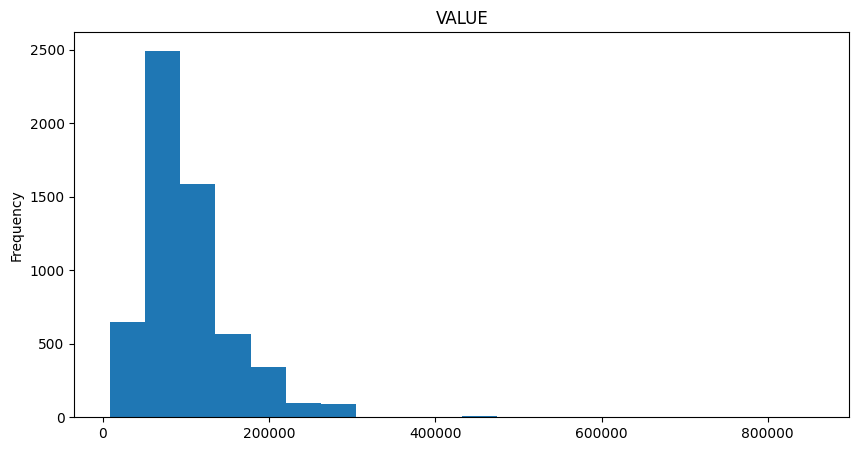

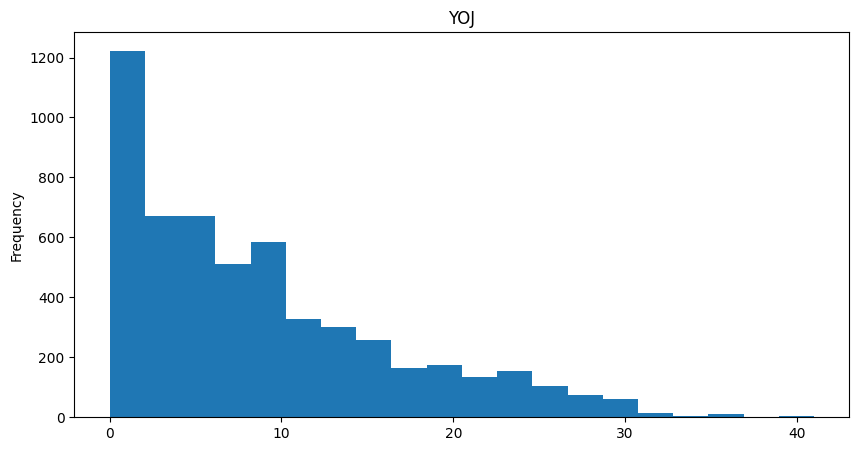

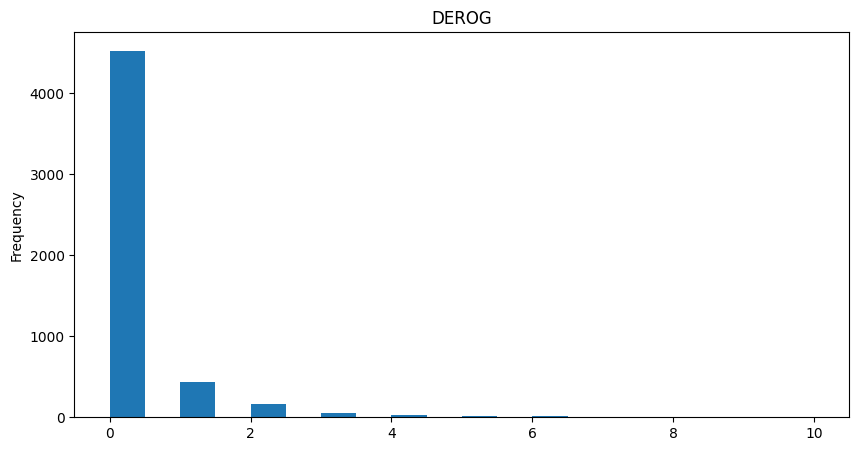

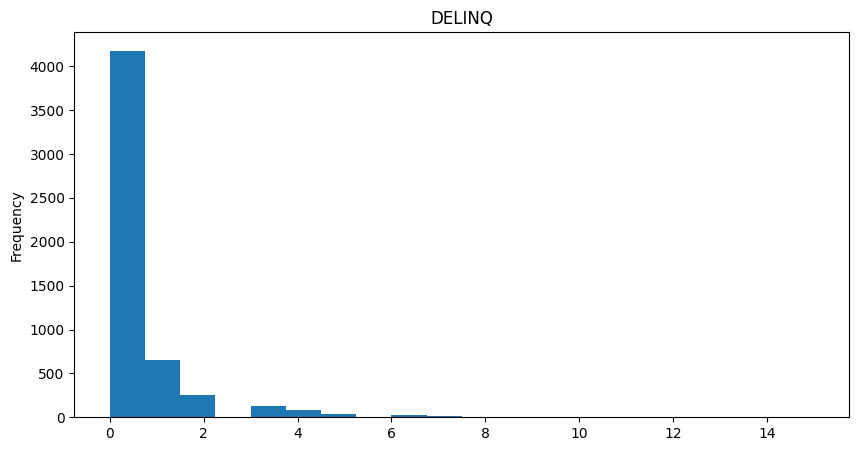

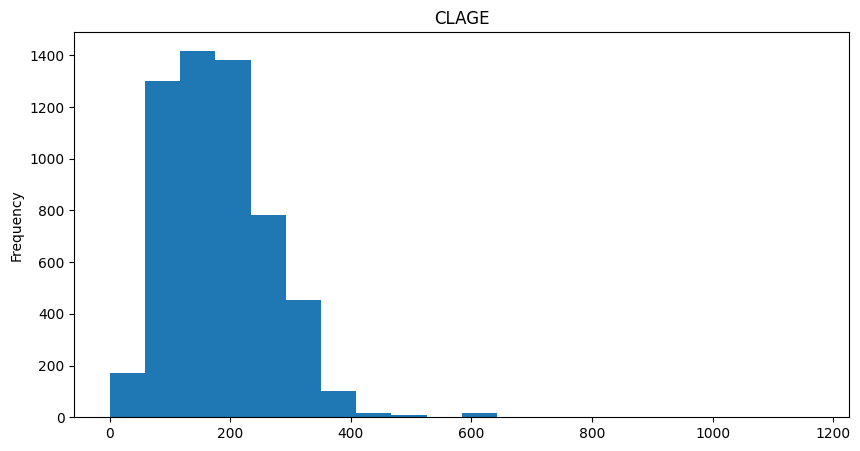

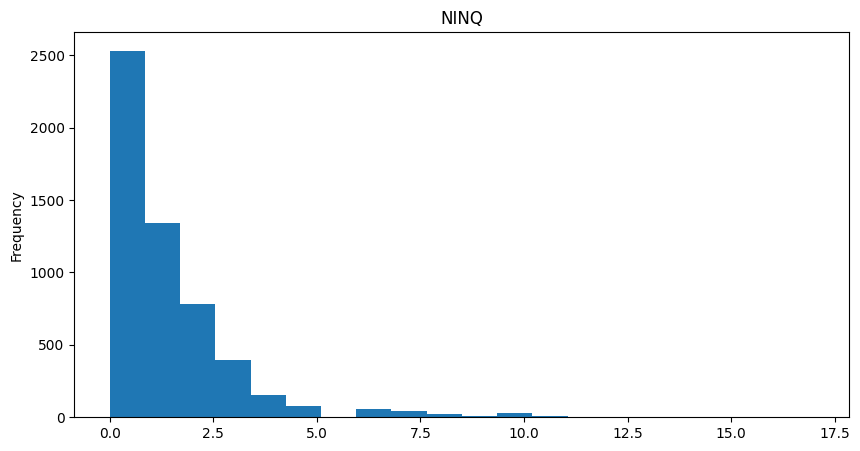

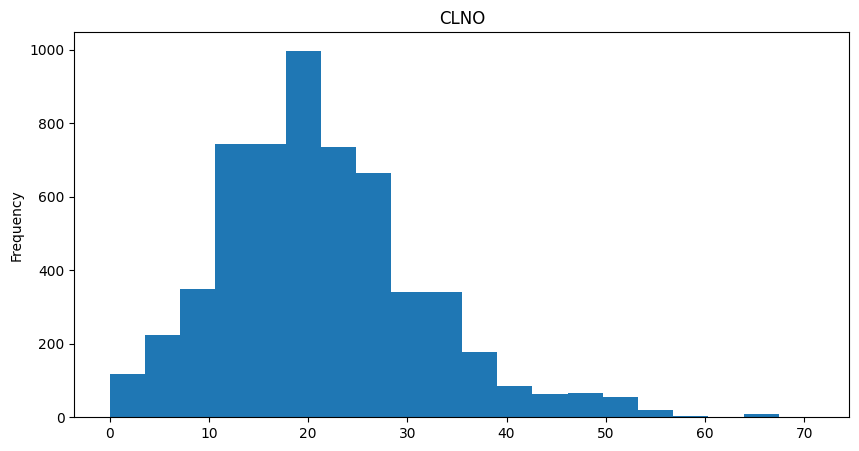

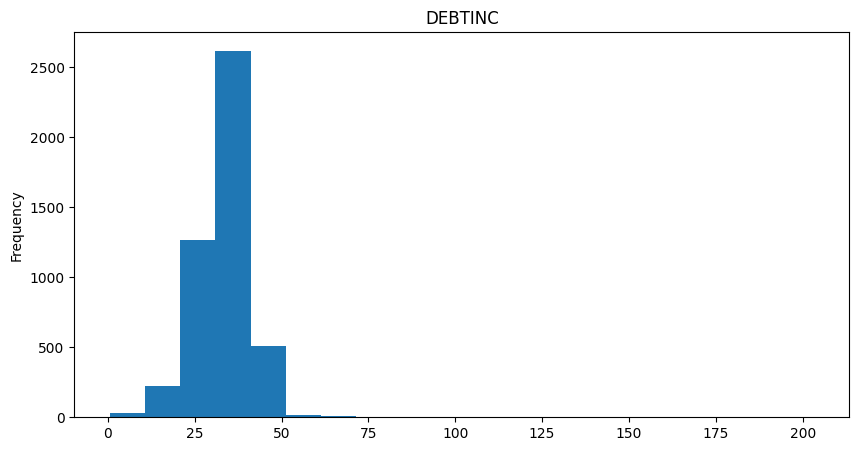

In [55]:
for col in num_cols:
    df[col].plot(kind='hist', figsize=(10,5), title=col, bins=20)
    plt.show()

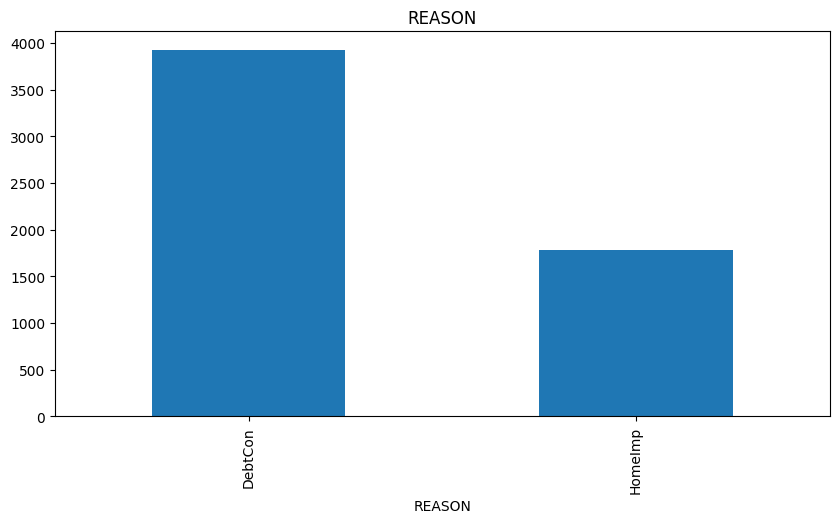

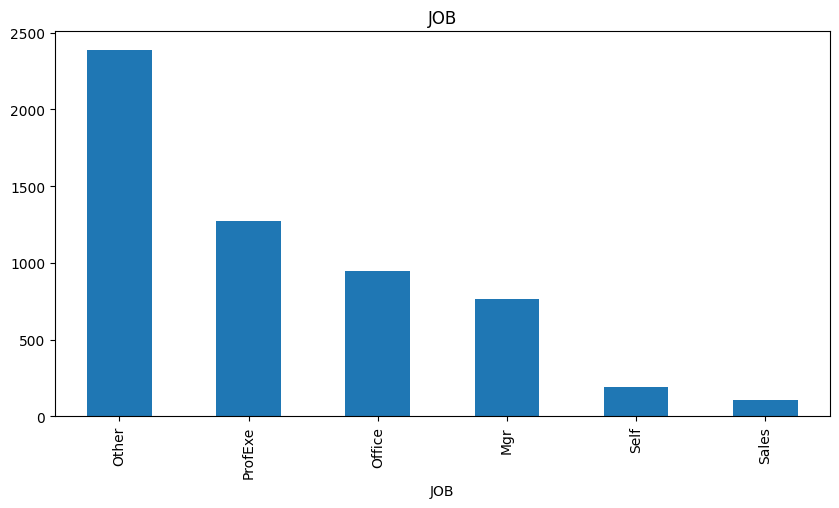

In [56]:
for col in cat_cols:
    df[col].value_counts().plot(kind='bar', figsize=(10,5), title=col)
    plt.show()

In [57]:
def list_binary_columns(df: pd.DataFrame) -> list:
    """
    Returns a list of column names in `df` that have exactly two unique non-null values.
    """
    binary_cols = []
    for col in df.columns:
        uniques = df[col].dropna().unique()
        if len(uniques) == 2:
            binary_cols.append(col)
    return binary_cols

binary_cols = list_binary_columns(df)
print("Binary columns:", binary_cols)

Binary columns: ['BAD', 'REASON']


In [58]:
binary_cols.remove('BAD')

In [59]:
binary_cols

['REASON']

# Bayesian

In [60]:
# Function for preprocessing and splitting the data
def preprocess_and_split(df, n_bins):
    dfc = df.copy()
    num_cols = dfc.select_dtypes(include=np.number).columns.difference(['BAD'])
    for col in num_cols:
        notna = dfc[col].notna()
        dfc.loc[notna, col] = pd.qcut(
            dfc.loc[notna, col], q=n_bins, duplicates='drop'
        ).astype(str)
    dfc['BAD'] = dfc['BAD'].astype(str)
    dfc = dfc.fillna('MISSING')
    return train_test_split(
        dfc, test_size=0.2,
        stratify=dfc['BAD'], random_state=42
    )

# Total evaluation pipeline function
def evaluate_structure(train_df, val_df, struct_config, metrics=None):
    # struct_config: dict with keys 'type' ('hill', 'tan', 'expert')
    # Learn or assign structure
    if struct_config['type'] == 'TAN':
        ts = TreeSearch(train_df)
        edges = ts.estimate(estimator_type='tan', class_node='BAD').edges()
    elif struct_config['type'] == 'hill':
        hc = HillClimbSearch(train_df)
        edges = hc.estimate(
            scoring_method=struct_config['score_obj'],
            max_indegree=struct_config['max_indeg']
        ).edges()
    elif struct_config['type'] == 'expert':
        edges = struct_config['edges']
    else:
        raise ValueError(f"Unknown struct type {struct_config['type']}")

    # Fit Bayesian model on learned structure
    model = DiscreteBayesianNetwork(edges)
    model.fit(train_df, estimator=BayesianEstimator, prior_type='BDeu')

    # Inference through variable elimination
    infer = VariableElimination(model)
    y_true = val_df['BAD'].astype(int).values
    probs = []
    y_pred = []
    for _, row in val_df.drop(columns='BAD').iterrows():
        ev = {v: row[v] for v in row.index if v in model.nodes()}
        q  = infer.query(['BAD'], evidence=ev, show_progress=False)
        p1 = q.values[1]
        probs.append(p1)
        y_pred.append(int(p1 >= 0.5))

    #Computation of metrics
    if metrics is None:
        metrics = {
            'roc_auc': roc_auc_score,
            'brier': brier_score_loss,
            'log_loss': lambda yt, yp: log_loss(yt, yp),
            'precision': lambda yt, yp: precision_score(yt, yp),
            'recall': lambda yt, yp: recall_score(yt, yp),
            'f1': lambda yt, yp: f1_score(yt, yp)
        }
    results = {}
    for name, func in metrics.items():
        if name in ['roc_auc', 'brier', 'log_loss']:
            results[name] = func(y_true, probs)
        else:
            results[name] = func(y_true, y_pred)
    return results

#Define structure configurations & metrics for the hill climb structure learning method
hill_scorers = {'K2': K2, 'BDeu': BDeu, 'BIC': BIC}
struct_configs = []
for name, Scorer in hill_scorers.items():
    for max_indeg in [3,4,5]:
        struct_configs.append({
            'type': 'hill',
            'scorer': name,
            'score_obj': None,  # placeholder
            'max_indeg': max_indeg
        })
# Tree-augmented Naive Bayes
struct_configs.append({'type': 'TAN'})
# "Expert" structure is based on a simple network structure of direct impacts on variables
expert_edges = [
    ('MORTDUE', 'VALUE'),
    ('VALUE',   'DEBTINC'),
    ('LOAN',    'DEBTINC'),
    ('DEROG',   'BAD'),
    ('DELINQ',  'BAD'),
    ('NINQ',    'BAD'),
    ('CLAGE',   'BAD'),
    ('CLNO',    'BAD'),
    ('DEBTINC', 'BAD'),
    ('REASON',  'BAD'),
    ('JOB',     'BAD')
]
struct_configs.append({'type': 'expert', 'edges': expert_edges})


# 4) Grid search over binning and structures
results = []
for n_bins in [3,4,5]:
    train_val_df, test_df = preprocess_and_split(df, n_bins)
    train_df, val_df = train_test_split(
        train_val_df, test_size=0.15,
        stratify=train_val_df['BAD'], random_state=42
    )
    for config in struct_configs:
        # initialize scorer object for hill configs
        if config['type'] == 'hill':
            Scorer = hill_scorers[config['scorer']]
            config['score_obj'] = Scorer(train_df)
        m_res = evaluate_structure(train_df, val_df, config)
        # record config details
        rec = {'n_bins': n_bins, 'type': config['type']}
        rec.update({k: config[k] for k in ['scorer','max_indeg'] if k in config})
        rec.update(m_res)
        results.append(rec)

# 5) Summarize results
df_results = pd.DataFrame(results)
df_results.sort_values('roc_auc', ascending=False).reset_index(drop=True)


  0%|          | 0/1000000 [00:00<?, ?it/s]

  0%|          | 0/1000000 [00:00<?, ?it/s]

  0%|          | 0/1000000 [00:00<?, ?it/s]

  0%|          | 0/1000000 [00:00<?, ?it/s]

  0%|          | 0/1000000 [00:00<?, ?it/s]

...

  0%|          | 0/1000000 [00:00<?, ?it/s]

  0%|          | 0/1000000 [00:00<?, ?it/s]

Building tree:   0%|          | 0/78.0 [00:00<?, ?it/s]

Building tree:   0%|          | 0/78.0 [00:00<?, ?it/s]

,n_bins,type,scorer,max_indeg,roc_auc,brier,log_loss,precision,recall,f1
0,5,hill,BDeu,4.0,0.898601,0.090334,0.296057,0.730435,0.587413,0.651163
1,5,hill,BDeu,5.0,0.898601,0.090334,0.296057,0.730435,0.587413,0.651163
2,5,TAN,NaN,NaN,0.894592,0.096560,0.315623,0.690476,0.608392,0.646840
3,5,hill,BDeu,3.0,0.892432,0.093860,0.306098,0.666667,0.615385,0.640000
4,5,hill,BIC,5.0,0.892408,0.092879,0.304278,0.694444,0.524476,0.597610
5,5,hill,BIC,4.0,0.892408,0.092879,0.304278,0.694444,0.524476,0.597610
6,5,hill,BIC,3.0,0.892408,0.092879,0.304278,0.694444,0.524476,0.597610
7,4,TAN,NaN,NaN,0.888612,0.092358,0.313778,0.736842,0.685315,0.710145
8,4,hill,K2,3.0,0.885287,0.095456,0.313065,0.704000,0.615385,0.656716
9,3,hill,K2,3.0,0.882614,0.096273,0.315351,0.677419,0.587413,0.629213


In [61]:
# Find best model config
best_idx = df_results['roc_auc'].idxmax()
best_row = df_results.loc[best_idx]

print("Best validation config:")
print(best_row[['n_bins', 'type', 'scorer', 'max_indeg', 'roc_auc']])

# Redo the split for THIS n_bins
train_val_df, test_df = preprocess_and_split(df, int(best_row['n_bins']))

# Retrain on full train_val_df
best_cfg = {'type': best_row['type']}
if best_row['type'] == 'hill':
    best_cfg['score_obj'] = hill_scorers[best_row['scorer']](train_val_df)
    best_cfg['max_indeg'] = int(best_row['max_indeg'])

# Evaluate on test_df
test_results = evaluate_structure(train_val_df, test_df, best_cfg)

print("\nTest‐set performance of best model:")
print(test_results)


Best validation config:
n_bins              5
type             hill
scorer           BDeu
max_indeg         4.0
roc_auc      0.898601
Name: 26, dtype: object


  0%|          | 0/1000000 [00:00<?, ?it/s]


Test‐set performance of best model:
{'roc_auc': np.float64(0.8812915103148178), 'brier': np.float64(0.09401074415398336), 'log_loss': 0.3184428801351673, 'precision': 0.7252747252747253, 'recall': 0.5546218487394958, 'f1': 0.6285714285714286}


In [62]:
# Sort results by validation AUC (descending)
top5_rows = df_results.sort_values('roc_auc', ascending=False).head(5)

print("Top 5 validation configs:")
print(top5_rows[['n_bins', 'type', 'scorer', 'max_indeg', 'roc_auc']])

# Store results
top5_test_results = []

# Loop through the top 5 configs
for i, row in top5_rows.iterrows():
    best_cfg = {'type': row['type']}

    if row['type'] == 'hill':
        best_cfg['score_obj'] = hill_scorers[row['scorer']](train_val_df)
        best_cfg['max_indeg'] = int(row['max_indeg'])

    # Evaluate on the test set
    test_res = evaluate_structure(train_val_df, test_df, best_cfg)
    test_res.update({
        'n_bins': row['n_bins'],
        'type': row['type'],
        'scorer': row.get('scorer', None),
        'max_indeg': row.get('max_indeg', None),
        'val_auc': row['roc_auc']
    })
    top5_test_results.append(test_res)

# Convert to DataFrame for easy viewing
df_top5_test = pd.DataFrame(top5_test_results)

print("\nTest‐set performance of top 5 models:")
df_top5_test.sort_values('roc_auc', ascending=False).head()

Top 5 validation configs:
    n_bins  type scorer  max_indeg   roc_auc
26       5  hill   BDeu        4.0  0.898601
27       5  hill   BDeu        5.0  0.898601
31       5   TAN    NaN        NaN  0.894592
25       5  hill   BDeu        3.0  0.892432
30       5  hill    BIC        5.0  0.892408


  0%|          | 0/1000000 [00:00<?, ?it/s]

  0%|          | 0/1000000 [00:00<?, ?it/s]

Building tree:   0%|          | 0/78.0 [00:00<?, ?it/s]

Building tree:   0%|          | 0/78.0 [00:00<?, ?it/s]

  0%|          | 0/1000000 [00:00<?, ?it/s]

  0%|          | 0/1000000 [00:00<?, ?it/s]


Test‐set performance of top 5 models:


,roc_auc,brier,log_loss,precision,recall,f1,n_bins,type,scorer,max_indeg,val_auc
2,0.883375,0.094863,0.313344,0.695431,0.575630,0.629885,5,TAN,NaN,NaN,0.894592
0,0.881292,0.094011,0.318443,0.725275,0.554622,0.628571,5,hill,BDeu,4.0,0.898601
1,0.881292,0.094011,0.318443,0.725275,0.554622,0.628571,5,hill,BDeu,5.0,0.898601
4,0.870772,0.099395,0.325782,0.703911,0.529412,0.604317,5,hill,BIC,5.0,0.892408
3,0.853879,0.102498,0.339498,0.656904,0.659664,0.658281,5,hill,BDeu,3.0,0.892432



=== Best for roc_auc: hill, bins=5, scorer=BDeu max_indeg=4.0 ===


  0%|          | 0/1000000 [00:00<?, ?it/s]

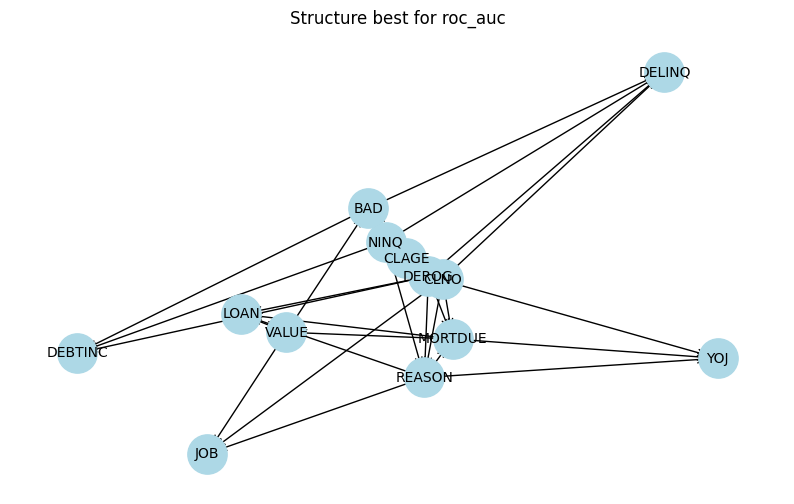


=== Best for brier: hill, bins=5, scorer=BDeu max_indeg=4.0 ===


  0%|          | 0/1000000 [00:00<?, ?it/s]

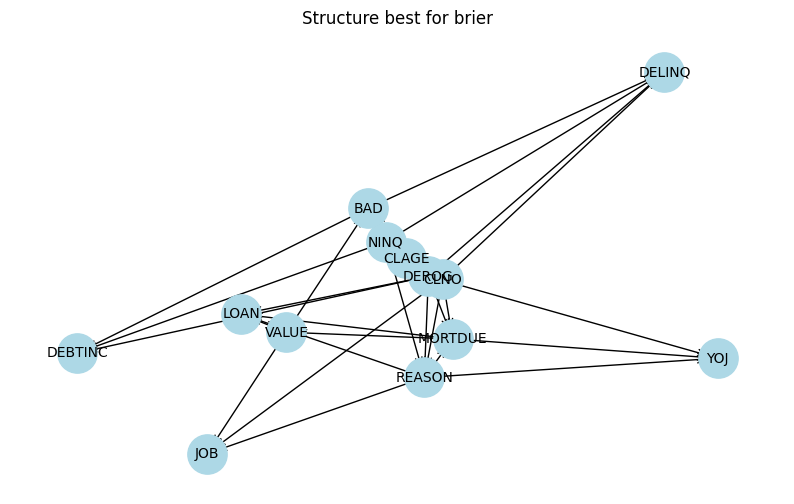


=== Best for log_loss: hill, bins=5, scorer=BDeu max_indeg=4.0 ===


  0%|          | 0/1000000 [00:00<?, ?it/s]

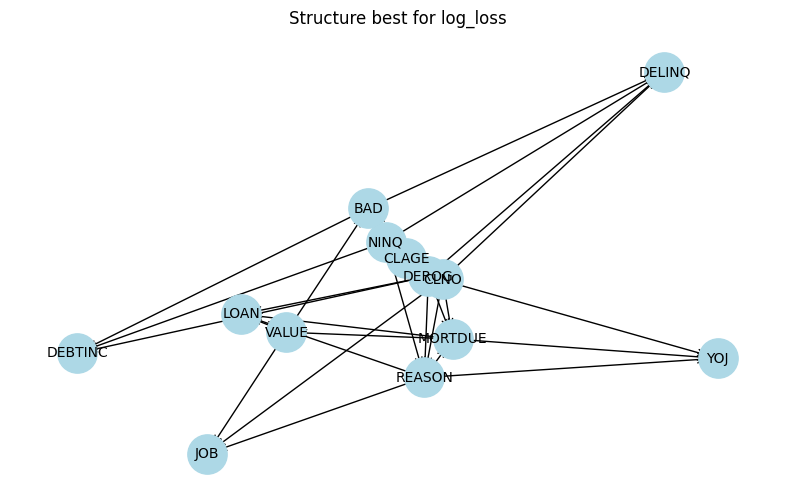


=== Best for precision: TAN, bins=4, scorer=nan max_indeg=nan ===


Building tree:   0%|          | 0/78.0 [00:00<?, ?it/s]

Building tree:   0%|          | 0/78.0 [00:00<?, ?it/s]

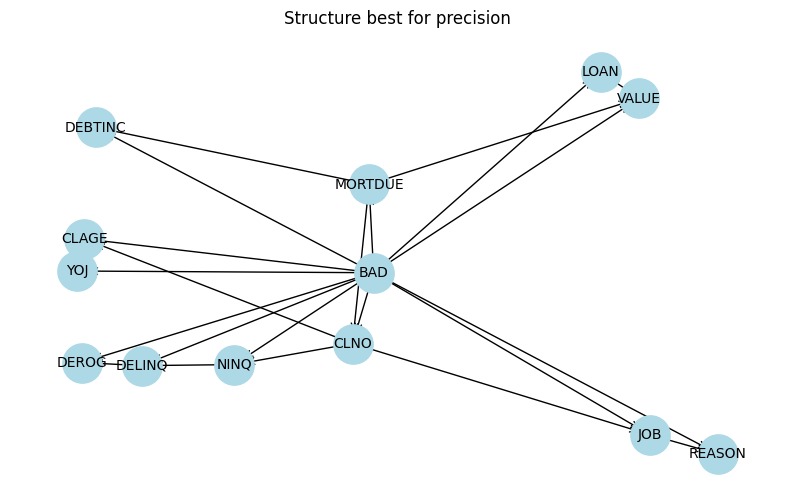


=== Best for recall: expert, bins=5, scorer=nan max_indeg=nan ===


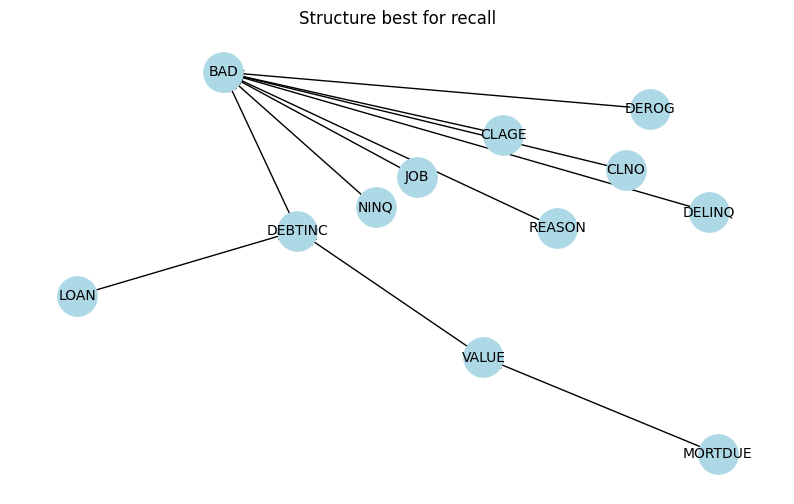


=== Best for f1: TAN, bins=4, scorer=nan max_indeg=nan ===


Building tree:   0%|          | 0/78.0 [00:00<?, ?it/s]

Building tree:   0%|          | 0/78.0 [00:00<?, ?it/s]

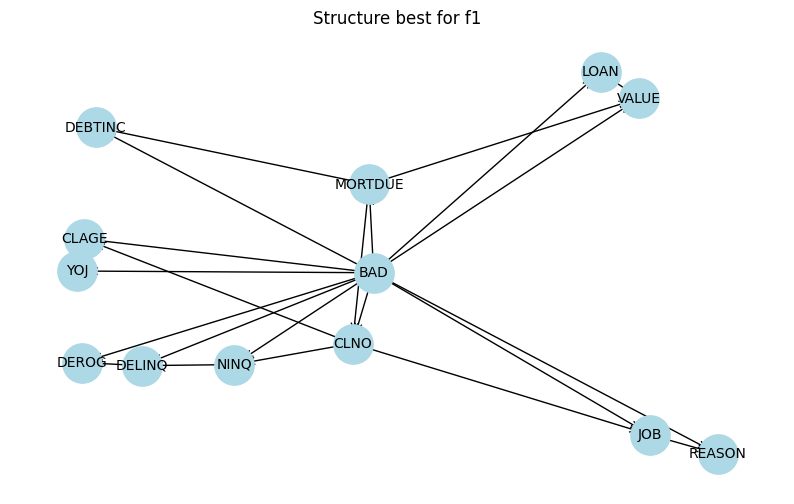

In [63]:
import pandas as pd
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    roc_auc_score, brier_score_loss, log_loss,
    precision_score, recall_score, f1_score
)
from pgmpy.models import DiscreteBayesianNetwork
from pgmpy.estimators import (
    HillClimbSearch, K2, BDeu, BIC, TreeSearch,
    BayesianEstimator
)
from pgmpy.inference import VariableElimination

# … (insert your preprocess_and_split and evaluate_structure here) …

# == 1) run your grid search, get df_results ==
# (assume df_results as per your last snippet)

# metrics you tracked:
metrics = ['roc_auc', 'brier', 'log_loss', 'precision', 'recall', 'f1']
to_minimize = {'brier', 'log_loss'}

# == 2) pick best config per metric ==
best_rows = []
for m in metrics:
    if m in to_minimize:
        idx = df_results[m].idxmin()
    else:
        idx = df_results[m].idxmax()
    row = df_results.loc[idx].to_dict()
    row['metric'] = m
    best_rows.append(row)
best_df = pd.DataFrame(best_rows)

# == 3) for each best config: rebuild edges, draw graph ==
# reuse your hill_scorers & expert_edges definitions
hill_scorers = {'K2': K2, 'BDeu': BDeu, 'BIC': BIC}
expert_edges = [
    ('MORTDUE','VALUE'),('VALUE','DEBTINC'),('LOAN','DEBTINC'),
    ('DEROG','BAD'),('DELINQ','BAD'),('NINQ','BAD'),
    ('CLAGE','BAD'),('CLNO','BAD'),('DEBTINC','BAD'),
    ('REASON','BAD'),('JOB','BAD')
]

for _, cfg in best_df.iterrows():
    m = cfg['metric']
    n_bins   = cfg['n_bins']
    struct_t = cfg['type']
    print(f"\n=== Best for {m}: {struct_t}, bins={n_bins}, scorer={cfg.get('scorer')} max_indeg={cfg.get('max_indeg')} ===")

    # re-split same way as grid
    train_df, test_df = preprocess_and_split(df, n_bins)

    # learn or load edges
    if struct_t == 'expert':
        edges = expert_edges
    elif struct_t == 'TAN':
        ts = TreeSearch(train_df)
        edges = list(ts.estimate(estimator_type='tan', class_node='BAD').edges())
    else:  # hill
        scorer = hill_scorers[cfg['scorer']](train_df)
        hc = HillClimbSearch(train_df)
        edges = list(hc.estimate(
            scoring_method=scorer,
            max_indegree=int(cfg['max_indeg'])
        ).edges())

    # draw with networkx
    G = nx.DiGraph()
    G.add_edges_from(edges)

    plt.figure(figsize=(10,6))
    pos = nx.spring_layout(G, seed=42)
    nx.draw_networkx_nodes(G, pos, node_size=800, node_color='lightblue')
    nx.draw_networkx_labels(G, pos, font_size=10)
    nx.draw_networkx_edges(G, pos, arrowstyle='->', arrowsize=12)
    plt.title(f"Structure best for {m}")
    plt.axis('off')
    plt.show()

  0%|          | 0/1000000 [00:00<?, ?it/s]

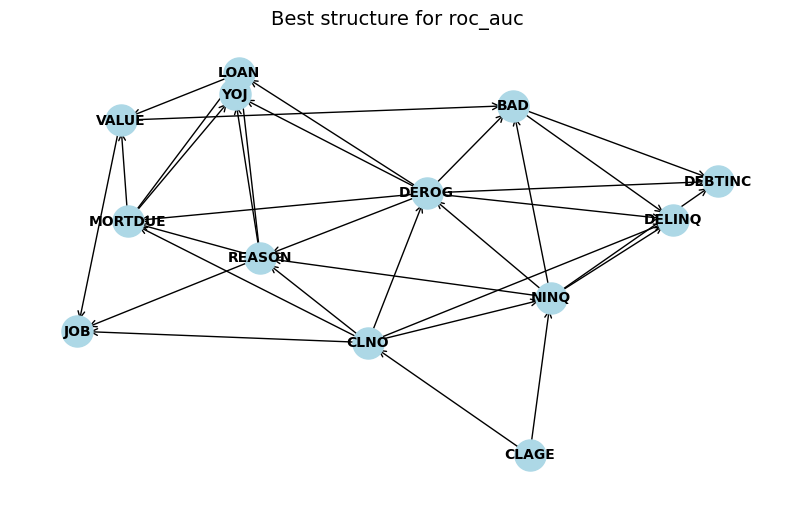

  0%|          | 0/1000000 [00:00<?, ?it/s]

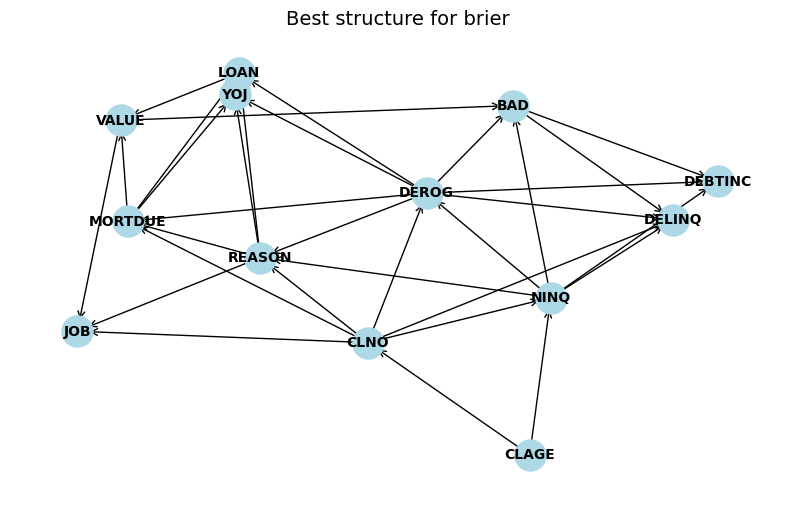

  0%|          | 0/1000000 [00:00<?, ?it/s]

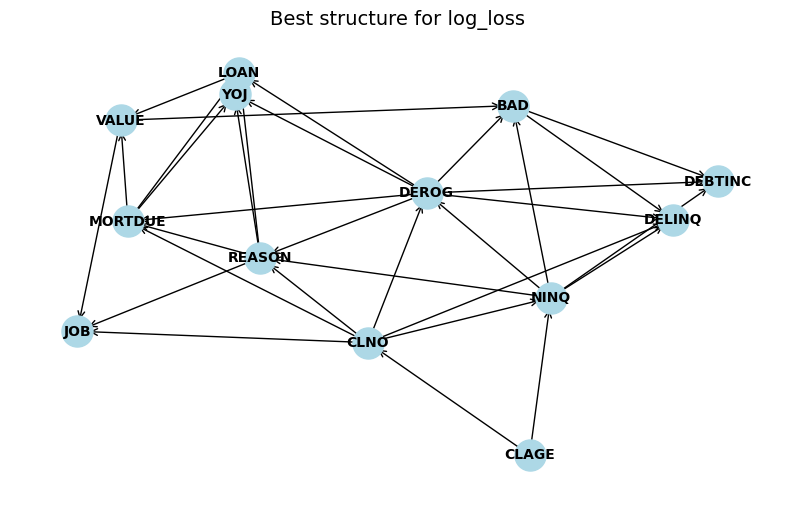

Building tree:   0%|          | 0/78.0 [00:00<?, ?it/s]

Building tree:   0%|          | 0/78.0 [00:00<?, ?it/s]

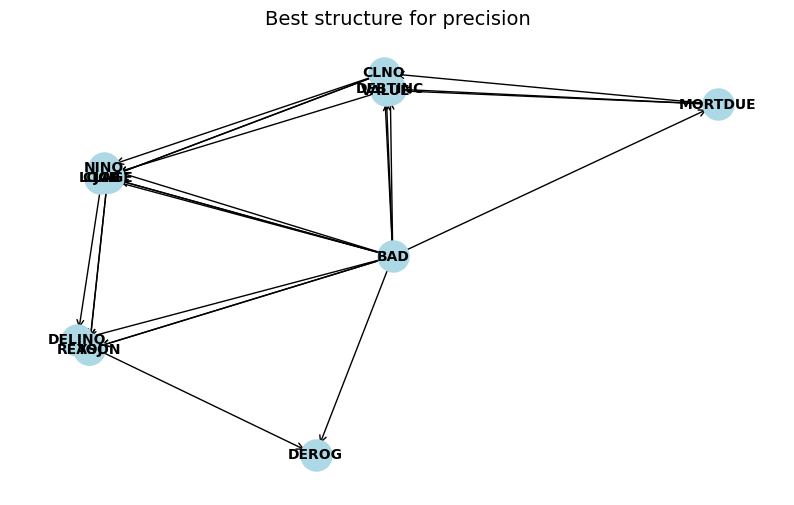

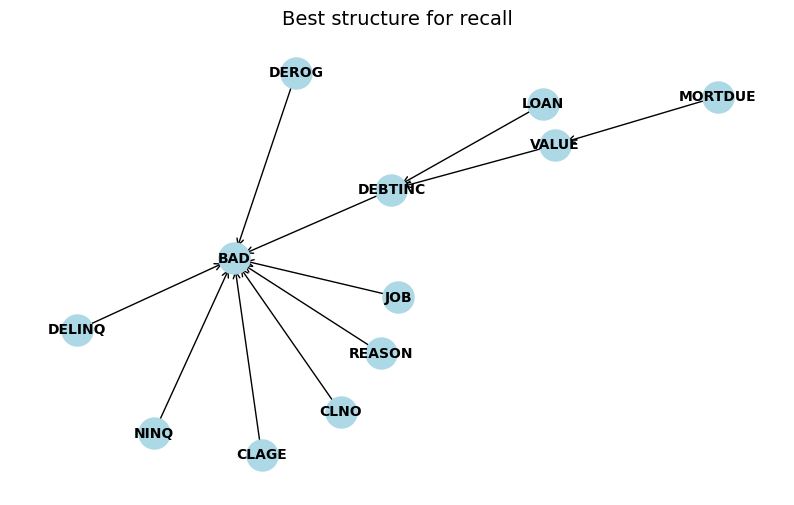

Building tree:   0%|          | 0/78.0 [00:00<?, ?it/s]

Building tree:   0%|          | 0/78.0 [00:00<?, ?it/s]

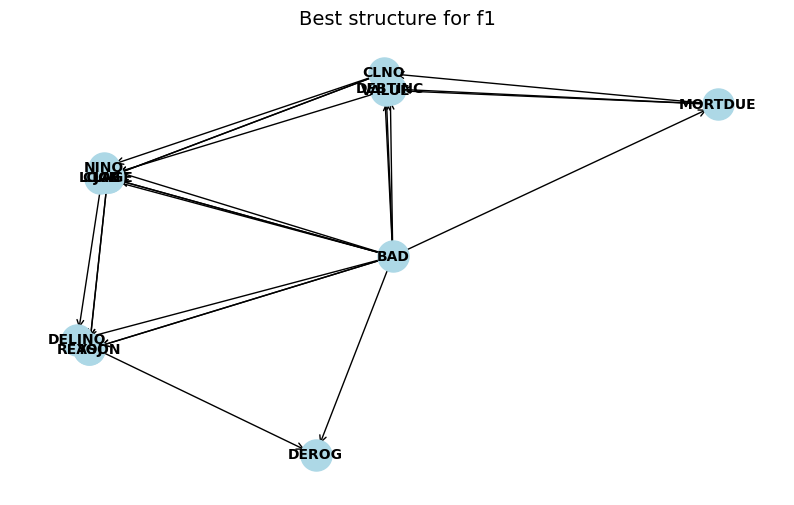

In [64]:
import pandas as pd
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    roc_auc_score, brier_score_loss, log_loss,
    precision_score, recall_score, f1_score
)
from pgmpy.models import DiscreteBayesianNetwork
from pgmpy.estimators import (
    HillClimbSearch, K2, BDeu, BIC, TreeSearch,
    BayesianEstimator
)
from pgmpy.inference import VariableElimination

# … (insert your preprocess_and_split and evaluate_structure here) …

# == 1) run your grid search, get df_results ==
# (assume df_results as per your last snippet)

# metrics you tracked:
metrics = ['roc_auc', 'brier', 'log_loss', 'precision', 'recall', 'f1']
to_minimize = {'brier', 'log_loss'}

# == 2) pick best config per metric ==
best_rows = []
for m in metrics:
    if m in to_minimize:
        idx = df_results[m].idxmin()
    else:
        idx = df_results[m].idxmax()
    row = df_results.loc[idx].to_dict()
    row['metric'] = m
    best_rows.append(row)
best_df = pd.DataFrame(best_rows)

# == 3) for each best config: rebuild edges, draw graph ==
# reuse your hill_scorers & expert_edges definitions
hill_scorers = {'K2': K2, 'BDeu': BDeu, 'BIC': BIC}
expert_edges = [
    ('MORTDUE','VALUE'),('VALUE','DEBTINC'),('LOAN','DEBTINC'),
    ('DEROG','BAD'),('DELINQ','BAD'),('NINQ','BAD'),
    ('CLAGE','BAD'),('CLNO','BAD'),('DEBTINC','BAD'),
    ('REASON','BAD'),('JOB','BAD')
]

import networkx as nx
import matplotlib.pyplot as plt
from networkx.drawing.nx_agraph import graphviz_layout  # if you have pygraphviz/pydot

for _, cfg in best_df.iterrows():
    m        = cfg['metric']
    n_bins   = cfg['n_bins']
    struct_t = cfg['type']

    # re-split same as before
    train_df, test_df = preprocess_and_split(df, n_bins)

    # pick edges
    if struct_t == 'expert':
        edges = expert_edges
    elif struct_t == 'TAN':
        ts = TreeSearch(train_df)
        edges = list(ts.estimate(estimator_type='tan', class_node='BAD').edges())
    else:
        scorer = hill_scorers[cfg['scorer']](train_df)
        hc = HillClimbSearch(train_df)
        edges = list(hc.estimate(
            scoring_method=scorer,
            max_indegree=int(cfg['max_indeg'])
        ).edges())

    G = nx.DiGraph()
    G.add_edges_from(edges)

    plt.figure(figsize=(10, 6))
    plt.title(f"Best structure for {m}", fontsize=14)

    try:
        # if you have pygraphviz/pydot installed:
        pos = graphviz_layout(G, prog='dot')
    except Exception:
        # fallback to Kamada–Kawai
        pos = nx.kamada_kawai_layout(G)

    nx.draw_networkx_nodes(G, pos,
                           node_size=500,
                           node_color='lightblue',
                           linewidths=1)
    nx.draw_networkx_labels(G, pos,
                            font_size=10,
                            font_weight='bold')
    nx.draw_networkx_edges(G, pos,
                           arrowstyle='->',
                           arrowsize=12,
                           width=1)

    plt.axis('off')
    plt.show()


In [65]:
# Compute node importance via degree centrality
degree_centrality = nx.degree_centrality(G)
important_nodes = sorted(degree_centrality.items(), key=lambda x: x[1], reverse=True)

print("\nTop 5 Important Nodes by Degree Centrality:")
for node, score in important_nodes[:5]:
    print(f"{node}: {score:.3f}")


Top 5 Important Nodes by Degree Centrality:
BAD: 1.000
CLNO: 0.417
MORTDUE: 0.333
VALUE: 0.250
CLAGE: 0.250


In [33]:
# Prior: P(BAD=1)
prior = infer.query(['BAD'], show_progress=False)
p_bad_1_prior = prior.values[1]


feature_shifts = []

for feature in model.nodes():
    if feature == 'BAD':
        continue

    # Get all observed unique values in the training set
    unique_values = train_df[feature].unique()
    shifts = []

    for val in unique_values:
        try:
            q = infer.query(['BAD'], evidence={feature: val}, show_progress=False)
            p_bad_1 = q.values[1]
            shift = abs(p_bad_1 - p_bad_1_prior)
            shifts.append(shift)
        except Exception:
            continue  # skip if value causes inconsistency

    # Store average shift across all values
    if shifts:
        feature_shifts.append((feature, np.mean(shifts)))


NameError: name 'infer' is not defined

In [ ]:
# Rank by average posterior shift
sorted_features = sorted(feature_shifts, key=lambda x: x[1], reverse=True)

print("\nTop features influencing P(Y=1):")
for feature, shift in sorted_features[:10]:
    print(f"{feature}: Avg posterior shift = {shift:.4f}")



Top features influencing P(Y=1):
JOB: Avg posterior shift = 0.0186
REASON: Avg posterior shift = 0.0057


# ML Models

In [66]:
from sklearn.model_selection import StratifiedKFold, GridSearchCV, train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder, OrdinalEncoder
from sklearn.metrics import roc_auc_score, accuracy_score, f1_score, classification_report
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

#Train test split
X_train, X_test, y_train, y_test = train_test_split(
    df.drop(columns=['BAD']), df['BAD'],
    test_size=0.2, random_state=42, stratify=df['BAD']
)

num_cols = X_train.select_dtypes(include=['number']).columns.tolist()
cat_cols = X_train.select_dtypes(exclude=['number']).columns.tolist()
bin_cols = binary_cols

#Pipelines for variables
numeric_pipeline = Pipeline([
    ('impute', SimpleImputer(strategy='median')),
    ('scale',  StandardScaler())
])

binary_pipeline = Pipeline([
    ('impute', SimpleImputer(strategy='most_frequent')),
    ('encode', OrdinalEncoder())
])

categorical_pipeline = Pipeline([
    ('impute', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

preprocessor = ColumnTransformer([
    ('num', numeric_pipeline,  num_cols),
    ('bin', binary_pipeline,   bin_cols),
    ('cat', categorical_pipeline, cat_cols)
])

#Models + Hyperparams
models_and_grids = {
    "RandomForest": {
        "pipe": Pipeline([
            ('preproc', preprocessor),
            ('model',   RandomForestClassifier(random_state=42, n_jobs=-1))
        ]),
        "param_grid": {
            "model__n_estimators":     [200, 400],
            "model__max_depth":        [None, 10, 20],
            "model__min_samples_leaf": [1, 2, 4],
        }
    },
    "LogisticRegression": {
        "pipe": Pipeline([
            ('preproc', preprocessor),
            ('model',   LogisticRegression(random_state=42, max_iter=2000))
        ]),
        "param_grid": [
            {
                "model__solver":  ["liblinear"],
                "model__penalty": ["l1", "l2"],
                "model__C":       [0.01, 0.1, 1, 10]
            },
            {
                "model__solver":  ["saga"],
                "model__penalty": ["l1", "l2"],
                "model__C":       [0.01, 0.1, 1, 10]
            },
            {
                "model__solver":  ["saga"],
                "model__penalty": ["elasticnet"],
                "model__C":       [0.01, 0.1, 1, 10],
                "model__l1_ratio":[0.1, 0.5, 0.9]
            }
        ]
    },
    "XGBoost": {
        "pipe": Pipeline([
            ('preproc', preprocessor),
            ('model',   XGBClassifier(
                eval_metric='auc',
                random_state=42,
                tree_method="hist",
                n_jobs=-1,
                enable_categorical=False
            ))
        ]),
        "param_grid": {
            "model__n_estimators":  [200, 400],
            "model__max_depth":     [3, 6, 10],
            "model__learning_rate": [0.01, 0.1]
        }
    }
}

#Cross-Validation with GridSearch
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
scoring = "roc_auc"

best_models = {}
for name, cfg in models_and_grids.items():
    grid = GridSearchCV(
        estimator=cfg["pipe"],
        param_grid=cfg["param_grid"],
        cv=cv,
        scoring=scoring,
        n_jobs=-1,
        refit=True,
        verbose=0
    )
    grid.fit(X_train, y_train)
    print(f"{name} best params: {grid.best_params_}")
    print(f"{name} best CV ROC AUC: {grid.best_score_:.3f}\n")
    best_models[name] = grid.best_estimator_


#Evaluate against test set
def evaluate(model_name, est, X_test, y_test):
    y_prob = est.predict_proba(X_test)[:, 1]
    y_pred = (y_prob >= 0.5).astype(int)
    return {
        "model": model_name,
        "test_roc_auc": roc_auc_score(y_test, y_prob),
        "test_accuracy": accuracy_score(y_test, y_pred),
        "test_f1": f1_score(y_test, y_pred),
        "report": classification_report(y_test, y_pred, digits=3)
    }

summaries = []
for name, est in best_models.items():
    s = evaluate(name, est, X_test, y_test)
    summaries.append(s)
    print(f"=== {name} ===")
    print(f"Test ROC AUC: {s['test_roc_auc']:.3f}")
    print(f"Test Accuracy: {s['test_accuracy']:.3f}")
    print(f"Test F1: {s['test_f1']:.3f}")
    print(s['report'])

winner = max(summaries, key=lambda d: d["test_roc_auc"])
print(f"\nWinner on TEST by ROC AUC: {winner['model']} ({winner['test_roc_auc']:.3f})")


RandomForest best params: {'model__max_depth': 20, 'model__min_samples_leaf': 1, 'model__n_estimators': 200}
RandomForest best CV ROC AUC: 0.968

LogisticRegression best params: {'model__C': 1, 'model__penalty': 'l1', 'model__solver': 'saga'}
LogisticRegression best CV ROC AUC: 0.812

XGBoost best params: {'model__learning_rate': 0.1, 'model__max_depth': 6, 'model__n_estimators': 400}
XGBoost best CV ROC AUC: 0.960

=== RandomForest ===
Test ROC AUC: 0.966
Test Accuracy: 0.913
Test F1: 0.745
              precision    recall  f1-score   support

           0      0.916     0.981     0.947       954
           1      0.894     0.639     0.745       238

    accuracy                          0.913      1192
   macro avg      0.905     0.810     0.846      1192
weighted avg      0.912     0.913     0.907      1192

=== LogisticRegression ===
Test ROC AUC: 0.764
Test Accuracy: 0.842
Test F1: 0.466
              precision    recall  f1-score   support

           0      0.855     0.966     

In [89]:
# Total evaluation pipeline function
def evaluate_structure(train_df, test_df, struct_config, metrics=None):
    if struct_config['type'] == 'hill':
        hc = HillClimbSearch(train_df)
        edges = hc.estimate(
            scoring_method=struct_config['score_obj'],
            max_indegree=struct_config['max_indeg']
        ).edges()
    else:
        raise ValueError(f"Unknown struct type {struct_config['type']}")

    # Fit Bayesian model on learned structure
    model = DiscreteBayesianNetwork(edges)
    model.fit(train_df, estimator=BayesianEstimator, prior_type='BDeu')

    # Inference through variable elimination
    infer = VariableElimination(model)
    y_true = test_df['BAD'].astype(int).values
    probs = []
    y_pred = []
    for _, row in test_df.drop(columns='BAD').iterrows():
        ev = {v: row[v] for v in row.index if v in model.nodes()}
        q  = infer.query(['BAD'], evidence=ev, show_progress=False)
        p1 = q.values[1]
        probs.append(p1)
        y_pred.append(int(p1 >= 0.5))

    # Computation of metrics
    if metrics is None:
        metrics = {
            'roc_auc': roc_auc_score,
            'brier': brier_score_loss,
            'log_loss': lambda yt, yp: log_loss(yt, yp),
            'precision': lambda yt, yp: precision_score(yt, yp),
            'recall': lambda yt, yp: recall_score(yt, yp),
            'f1': lambda yt, yp: f1_score(yt, yp)
        }
    results = {}
    for name, func in metrics.items():
        if name in ['roc_auc', 'brier', 'log_loss']:
            results[name] = func(y_true, probs)
        else:
            results[name] = func(y_true, y_pred)
    return results

# Define structure configurations & metrics for the hill climb structure learning method
hill_scorers = {'K2': K2, 'BDeu': BDeu, 'BIC': BIC}
struct_configs = []
for name, Scorer in hill_scorers.items():
    for max_indeg in [3,4,5]:
        struct_configs.append({
            'type': 'hill',
            'scorer': name,
            'score_obj': None,
            'max_indeg': max_indeg
        })
#Process
results = []
for n_bins in [3,4,5]:
    train_df, test_df = preprocess_and_split(df, n_bins)
    for config in struct_configs:
        if config['type'] == 'hill':
            Scorer = hill_scorers[config['scorer']]
            config['score_obj'] = Scorer(train_df)
        m_res = evaluate_structure(train_df, test_df, config)
        rec = {'n_bins': n_bins, 'type': config['type']}
        rec.update({k: config[k] for k in ['scorer','max_indeg'] if k in config})
        rec.update(m_res)
        results.append(rec)

# Summarize results
df_results = pd.DataFrame(results)
df_results.sort_values('roc_auc', ascending=False).reset_index(drop=True)

  0%|          | 0/1000000 [00:00<?, ?it/s]

  0%|          | 0/1000000 [00:00<?, ?it/s]

  0%|          | 0/1000000 [00:00<?, ?it/s]

  0%|          | 0/1000000 [00:00<?, ?it/s]

  0%|          | 0/1000000 [00:00<?, ?it/s]

...

  0%|          | 0/1000000 [00:00<?, ?it/s]

  0%|          | 0/1000000 [00:00<?, ?it/s]

  0%|          | 0/1000000 [00:00<?, ?it/s]

  0%|          | 0/1000000 [00:00<?, ?it/s]

,n_bins,type,scorer,max_indeg,roc_auc,brier,log_loss,precision,recall,f1
0,4,hill,K2,4,0.884630,0.089529,0.355762,0.761658,0.617647,0.682135
1,5,hill,BDeu,4,0.881292,0.094011,0.318443,0.725275,0.554622,0.628571
2,5,hill,BDeu,5,0.881292,0.094011,0.318443,0.725275,0.554622,0.628571
3,4,hill,K2,3,0.876944,0.097439,0.322690,0.683962,0.609244,0.644444
4,5,hill,K2,3,0.871501,0.098628,0.326674,0.645455,0.596639,0.620087
5,4,hill,BIC,5,0.870776,0.099999,0.328932,0.703297,0.537815,0.609524
6,4,hill,BIC,3,0.870776,0.099999,0.328932,0.703297,0.537815,0.609524
7,4,hill,BIC,4,0.870776,0.099999,0.328932,0.703297,0.537815,0.609524
8,5,hill,BIC,4,0.870772,0.099395,0.325782,0.703911,0.529412,0.604317
9,5,hill,BIC,3,0.870772,0.099395,0.325782,0.703911,0.529412,0.604317


Best BN by AUC → n_bins=3, scorer=K2, max_indeg=3, AUC=0.885


  0%|          | 0/1000000 [00:00<?, ?it/s]

,node,state,prob
0,BAD,0,0.799918
1,BAD,1,0.200082
2,CLAGE,"(-0.001, 128.622]",0.317879
3,CLAGE,"(128.622, 207.338]",0.316902
4,CLAGE,"(207.338, 1168.234]",0.311992
5,CLAGE,MISSING,0.053228
6,CLNO,"(-0.001, 16.0]",0.334386
7,CLNO,"(16.0, 24.0]",0.321223
8,CLNO,"(24.0, 71.0]",0.306943
9,CLNO,MISSING,0.037448


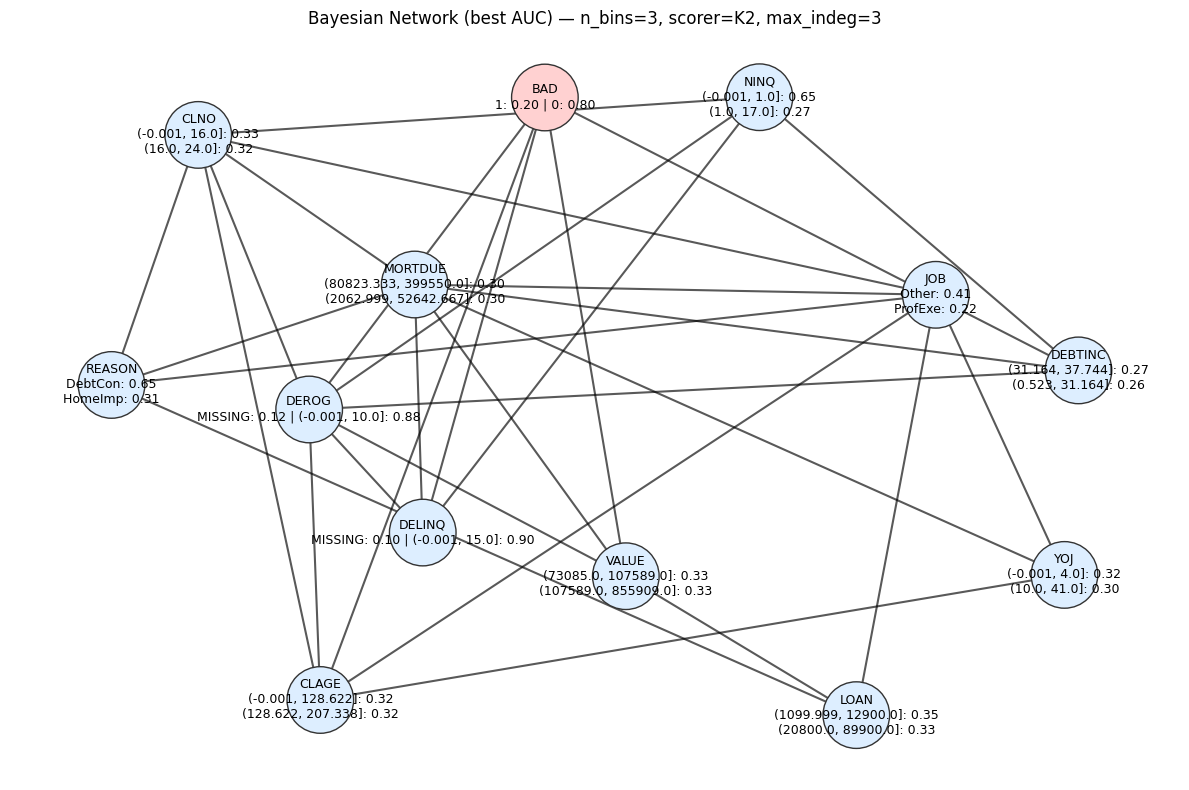

+--------+-----+--------------------+
| DELINQ | ... | DELINQ(MISSING)    |
+--------+-----+--------------------+
| DEROG  | ... | DEROG(MISSING)     |
+--------+-----+--------------------+
| VALUE  | ... | VALUE(MISSING)     |
+--------+-----+--------------------+
| BAD(0) | ... | 0.3030769230769231 |
+--------+-----+--------------------+
| BAD(1) | ... | 0.696923076923077  |
+--------+-----+--------------------+


In [104]:
# ===================== BN INTERPRETIVE VISUALIZATION (runs after your code) =====================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import networkx as nx

from pgmpy.estimators import BayesianEstimator

# 1) Pick best config by AUC from your results DataFrame
best_idx = df_results['roc_auc'].idxmax()
best_row = df_results.loc[best_idx]
n_bins_best = 3
scorer_name = best_row['scorer']
max_indeg   = 3

print(f"Best BN by AUC → n_bins={n_bins_best}, scorer={scorer_name}, max_indeg={max_indeg}, AUC={best_row['roc_auc']:.3f}")

# 2) Recreate data and learn the structure with that config
train_df_best, test_df_best = preprocess_and_split(df, n_bins_best)

score_map = {'K2': K2, 'BDeu': BDeu, 'BIC': BIC}
ScoreCls  = score_map[scorer_name]
scorer    = ScoreCls(train_df_best)

hc = HillClimbSearch(train_df_best)
estimated = hc.estimate(scoring_method=scorer, max_indegree=max_indeg)
edges = list(estimated.edges())

# 3) Fit parameters and set up inference
bn_model = DiscreteBayesianNetwork(edges)
bn_model.fit(train_df_best, estimator=BayesianEstimator, prior_type='BDeu')

infer = VariableElimination(bn_model)

# --- Helpers ---
def state_names_for(node):
    """Try to get human-readable state names from CPD; fall back to data."""
    cpd = bn_model.get_cpds(node)
    if hasattr(cpd, "state_names") and node in getattr(cpd, "state_names", {}):
        return list(cpd.state_names[node])
    # Fallback: state order from data (sorted for stability)
    return sorted(train_df_best[node].dropna().unique())

def node_label_with_marginals(node):
    """Build a compact label showing node name + key probabilities."""
    q = infer.query([node], show_progress=False)
    probs = np.ravel(q.values)
    states = state_names_for(node)
    if len(states) != len(probs):
        states = [f"{node}_{i}" for i in range(len(probs))]
    if len(states) == 2:
        # Binary: show both states
        return f"{node}\n{states[1]}: {probs[1]:.2f} | {states[0]}: {probs[0]:.2f}"
    else:
        order = np.argsort(-probs)
        top2 = [(states[i], probs[i]) for i in order[:2]]
        tops = "\n".join([f"{s}: {p:.2f}" for s,p in top2])
        return f"{node}\n{tops}"

# Build table of marginals for inspection/export
marginal_rows = []
for node in bn_model.nodes():
    q = infer.query([node], show_progress=False)
    probs = np.ravel(q.values)
    states = state_names_for(node)
    if len(states) != len(probs):
        states = [f"{node}_{i}" for i in range(len(probs))]
    for s, p in zip(states, probs):
        marginal_rows.append({"node": node, "state": str(s), "prob": float(p)})

marginal_df = pd.DataFrame(marginal_rows).sort_values(["node","state"]).reset_index(drop=True)
display(marginal_df.head(20))  # peek

# 4) Draw the network with labels
G = nx.DiGraph()
G.add_nodes_from(bn_model.nodes())
G.add_edges_from(edges)

# Try Graphviz layout (readable DAG). Fallback to spring layout if unavailable.
try:
    pos = nx.nx_agraph.graphviz_layout(G, prog="dot")
except Exception:
    pos = nx.spring_layout(G, seed=42, k=2)

# Node colors: emphasize BAD; others in a light tone
node_colors = []
for n in G.nodes():
    node_colors.append("#ffd1d1" if n == "BAD" else "#ddeeff")

plt.figure(figsize=(12, 8))
nx.draw_networkx_edges(G, pos, arrows=True, arrowstyle='-|>', arrowsize=16, width=1.5, alpha=0.65)
nx.draw_networkx_nodes(G, pos, node_color=node_colors, node_size=2300, edgecolors="#333", linewidths=1.0)

labels = {n: node_label_with_marginals(n) for n in G.nodes()}
nx.draw_networkx_labels(G, pos, labels=labels, font_size=9)

plt.title(f"Bayesian Network (best AUC) — n_bins={n_bins_best}, scorer={scorer_name}, max_indeg={max_indeg}")
plt.axis("off")
plt.tight_layout()
plt.show()

# 5) (Optional) Show BAD's local CPD as a readable table for governance
try:
    cpdbad = bn_model.get_cpds("BAD")
    print(cpdbad)  # pgmpy's own pretty print
except Exception:
    pass
# ================================================================================================


In [85]:
from sklearn.base import BaseEstimator, ClassifierMixin
from sklearn.utils.validation import check_is_fitted
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import KBinsDiscretizer, OrdinalEncoder
import numpy as np
import pandas as pd

from pgmpy.estimators import HillClimbSearch, K2, BIC, BDeu, BayesianEstimator
from pgmpy.inference import VariableElimination
from pgmpy.models import DiscreteBayesianNetwork

class BayesianNetworkClassifier(BaseEstimator, ClassifierMixin):
    def __init__(self, scorer="BDeu", max_indeg=3, prior_type="BDeu",
                 class_name="BAD", threshold=0.5, random_state=42):
        self.scorer = scorer
        self.max_indeg = max_indeg
        self.prior_type = prior_type
        self.class_name = class_name
        self.threshold = threshold
        self.random_state = random_state

    def _scorer_cls(self):
        return {"K2": K2, "BDeu": BDeu, "BIC": BIC}[self.scorer]

    def fit(self, X, y):
        if isinstance(X, pd.DataFrame):
            self.feature_names_in_ = np.array(list(X.columns))
            X_df = X.copy()
        else:
            self.feature_names_in_ = np.array([f"X{i}" for i in range(X.shape[1])])
            X_df = pd.DataFrame(X, columns=self.feature_names_in_)
        y = pd.Series(y).astype(int)
        Xy = X_df.copy()
        Xy[self.class_name] = y.values

        # ensure discrete ints for pgmpy
        for c in Xy.columns:
            if pd.api.types.is_float_dtype(Xy[c]):
                Xy[c] = np.round(Xy[c]).astype(int)
            elif pd.api.types.is_bool_dtype(Xy[c]):
                Xy[c] = Xy[c].astype(int)

        Scorer = self._scorer_cls()
        hc = HillClimbSearch(Xy, state_names={col: sorted(Xy[col].dropna().unique()) for col in Xy.columns})
        struct = hc.estimate(scoring_method=Scorer(Xy), max_indegree=self.max_indeg)
        self.model_ = DiscreteBayesianNetwork(struct.edges())
        self.model_.fit(Xy, estimator=BayesianEstimator, prior_type=self.prior_type)
        self.infer_ = VariableElimination(self.model_)
        self.classes_ = np.array([0, 1], dtype=int)
        return self

    def predict_proba(self, X):
        check_is_fitted(self, ["model_", "infer_", "feature_names_in_"])
        if isinstance(X, pd.DataFrame):
            X_df = X[self.feature_names_in_].copy()
        else:
            X_df = pd.DataFrame(X, columns=self.feature_names_in_)
        for c in X_df.columns:
            if pd.api.types.is_float_dtype(X_df[c]):
                X_df[c] = np.round(X_df[c]).astype(int)
            elif pd.api.types.is_bool_dtype(X_df[c]):
                X_df[c] = X_df[c].astype(int)

        probs = []
        for _, row in X_df.iterrows():
            ev = {v: int(row[v]) for v in X_df.columns if v in self.model_.nodes()}
            q = self.infer_.query([self.class_name], evidence=ev, show_progress=False)
            p1 = float(q.values[1])
            probs.append([1.0 - p1, p1])
        return np.array(probs)

    def predict(self, X):
        return (self.predict_proba(X)[:, 1] >= self.threshold).astype(int)


best_bn = df_results.iloc[0]
best_n_bins   = int(best_bn["n_bins"])
best_scorer   = best_bn.get("scorer", "BDeu")
best_max_deg  = int(best_bn.get("max_indeg", 3))


bn_num_cols = X_train.select_dtypes(include=["number"]).columns.tolist()

bn_numeric = Pipeline([
    ("impute", SimpleImputer(strategy="median")),
    ("kbins",  KBinsDiscretizer(n_bins=best_n_bins, encode="ordinal", strategy="quantile"))
])

bn_preproc = ColumnTransformer(
    [("num", bn_numeric, bn_num_cols)],
    remainder="drop"
)

bn_est = Pipeline([
    ("preproc", bn_preproc),
    ("model",   BayesianNetworkClassifier(
        scorer=best_scorer,
        max_indeg=best_max_deg,
        prior_type="BDeu",
        class_name="BAD",
        threshold=0.5,
        random_state=42
    ))
])


bn_est.fit(X_train, y_train)


best_models["BayesianNetwork"] = bn_est


bn_summary = evaluate("BayesianNetwork", bn_est, X_test, y_test)
summaries.append(bn_summary)
print(f"=== BayesianNetwork ===")
print(f"Test ROC AUC: {bn_summary['test_roc_auc']:.3f}")
print(f"Test Accuracy: {bn_summary['test_accuracy']:.3f}")
print(f"Test F1: {bn_summary['test_f1']:.3f}")
print(bn_summary["report"])

  0%|          | 0/1000000 [00:00<?, ?it/s]

=== BayesianNetwork ===
Test ROC AUC: 0.807
Test Accuracy: 0.810
Test F1: 0.347
              precision    recall  f1-score   support

           0      0.836     0.950     0.889       954
           1      0.556     0.252     0.347       238

    accuracy                          0.810      1192
   macro avg      0.696     0.601     0.618      1192
weighted avg      0.780     0.810     0.781      1192



# TEST


RandomForest:
  • AUC = 0.966
  • Youden threshold = 0.207 (TPR=0.933, FPR=0.101)
              precision    recall  f1-score   support

           0       0.98      0.90      0.94       954
           1       0.70      0.93      0.80       238

    accuracy                           0.91      1192
   macro avg       0.84      0.92      0.87      1192
weighted avg       0.93      0.91      0.91      1192


LogisticRegression:
  • AUC = 0.764
  • Youden threshold = 0.196 (TPR=0.618, FPR=0.216)
              precision    recall  f1-score   support

           0       0.89      0.78      0.83       954
           1       0.42      0.62      0.50       238

    accuracy                           0.75      1192
   macro avg       0.65      0.70      0.67      1192
weighted avg       0.80      0.75      0.77      1192


XGBoost:
  • AUC = 0.955
  • Youden threshold = 0.059 (TPR=0.912, FPR=0.103)
              precision    recall  f1-score   support

           0       0.98      0.90      0.

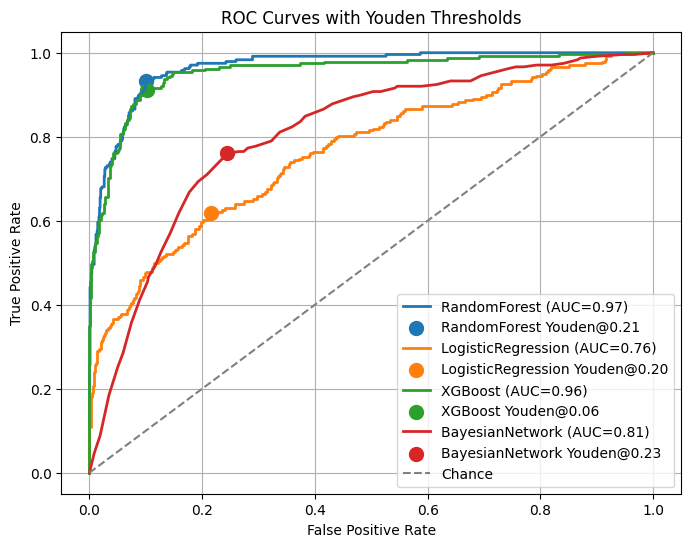

In [86]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc, classification_report

plt.figure(figsize=(8,6))

for name, model in best_models.items():
    # 1) Get the predicted probabilities for the positive class
    y_scores = model.predict_proba(X_test)[:, 1]

    # 2) Compute ROC curve
    fpr, tpr, thresholds = roc_curve(y_test, y_scores)
    roc_auc = auc(fpr, tpr)

    # 3) Find Youden's J = TPR - FPR
    youden_j = tpr - fpr
    idx = np.argmax(youden_j)
    youden_thresh = thresholds[idx]
    print(f"\n{name}:")
    print(f"  • AUC = {roc_auc:.3f}")
    print(f"  • Youden threshold = {youden_thresh:.3f} "
          f"(TPR={tpr[idx]:.3f}, FPR={fpr[idx]:.3f})")

    # 4) Threshold into class predictions
    y_pred = (y_scores >= youden_thresh).astype(int)

    # 5) Classification report at that threshold
    print(classification_report(y_test, y_pred))

    # 6) Plot ROC curve and mark the Youden point
    plt.plot(fpr, tpr, lw=2, label=f'{name} (AUC={roc_auc:.2f})')
    plt.scatter(fpr[idx], tpr[idx],
                marker='o', s=100,
                label=f'{name} Youden@{youden_thresh:.2f}')

# chance line
plt.plot([0,1],[0,1],'--', color='gray', label='Chance')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curves with Youden Thresholds')
plt.legend(loc='lower right')
plt.grid(True)
plt.show()

In [ ]:
import numpy as np
from sklearn.metrics import roc_curve

def _sample_k(p0_mass=0.2, p1_mass=0.3, n_uniform=100, rng=None):
    rng = np.random.default_rng(None if rng is None else rng)
    n0 = int(round(p0_mass * n_uniform))
    n1 = int(round(p1_mass * n_uniform))
    nunif = max(n_uniform - n0 - n1, 0)
    ks = np.concatenate([np.zeros(n0), np.ones(n1), rng.uniform(0, 1, nunif)])
    return ks

def ep_curve(y_true_bad, y_scores_bad, ROI, p0_mass=0.2, p1_mass=0.3, n_uniform=100, rng=None):
    """
    Expected profit at a common threshold across k~mixture. Not EMP per paper,
    but handy to visualize how a single threshold would perform in expectation.
    """
    y_true_good = 1 - y_true_bad
    y_scores_good = 1 - y_scores_bad
    fpr, tpr, thr = roc_curve(y_true_good, y_scores_good)

    p_good = np.mean(y_true_good == 1)
    p_bad  = 1 - p_good
    ks = _sample_k(p0_mass, p1_mass, n_uniform, rng)

    reject_bads  = 1 - fpr
    reject_goods = 1 - tpr
    ep = (p_bad * reject_bads[None, :] * ks[:, None]) - (ROI * p_good * reject_goods[None, :])
    ep_mean = ep.mean(axis=0)
    best_idx = np.argmax(ep_mean)
    return thr, ep_mean, best_idx

def emp_value(y_true_bad, y_scores_bad, ROI, p0_mass=0.2, p1_mass=0.3, n_uniform=100, rng=None):
    """
    E_k[ max_t P(t; k, ROI) ] computed via Monte Carlo over k and grid over ROC thresholds.
    """
    y_true_good = 1 - y_true_bad
    y_scores_good = 1 - y_scores_bad
    fpr, tpr, thr = roc_curve(y_true_good, y_scores_good)

    p_good = np.mean(y_true_good == 1)
    p_bad  = 1 - p_good
    ks = _sample_k(p0_mass, p1_mass, n_uniform, rng)

    reject_bads  = 1 - fpr
    reject_goods = 1 - tpr

    P = (p_bad * reject_bads[None, :] * ks[:, None]) - (ROI * p_good * reject_goods[None, :])
    P_star = P.max(axis=1)
    EMP = P_star.mean()
    best_idx = P.mean(axis=0).argmax()
    return EMP, thr[best_idx]


RandomForest → EMP = 0.0860  | EP-best(thr) = 0.0812 at thr=0.795
LogisticRegression → EMP = 0.0383  | EP-best(thr) = 0.0319 at thr=0.691
XGBoost → EMP = 0.0888  | EP-best(thr) = 0.0857 at thr=0.896
BayesianNetwork → EMP = 0.0457  | EP-best(thr) = 0.0367 at thr=0.702


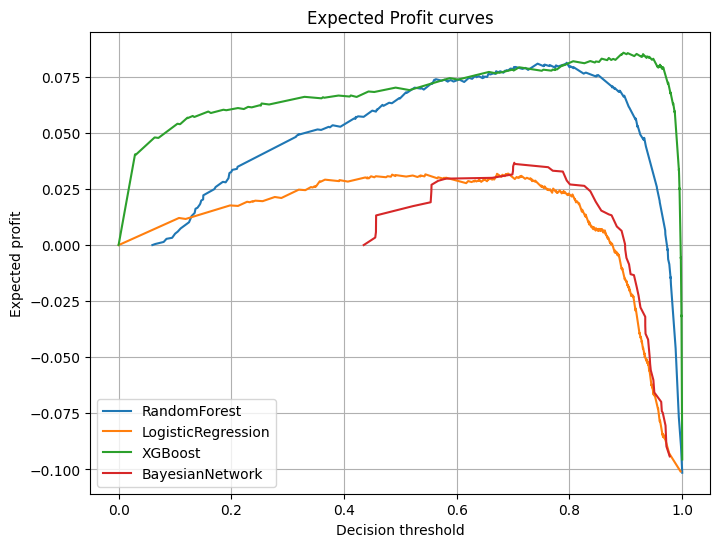

In [ ]:
ROI = 0.2644
p0_mass = 0.2
p1_mass = 0.3

import matplotlib.pyplot as plt
plt.figure(figsize=(8,6))

for name, model in best_models.items():
    y_scores_bad = model.predict_proba(X_test)[:, 1]
    thr, ep_vals, ep_idx = ep_curve(
        y_true_bad=y_test.values,
        y_scores_bad=y_scores_bad,
        ROI=ROI, p0_mass=p0_mass, p1_mass=p1_mass, n_uniform=200
    )
    EMP, emp_thr = emp_value(
        y_true_bad=y_test.values,
        y_scores_bad=y_scores_bad,
        ROI=ROI, p0_mass=p0_mass, p1_mass=p1_mass, n_uniform=200
    )
    print(f"{name} → EMP = {EMP:.4f}  | EP-best(thr) = {ep_vals[ep_idx]:.4f} at thr={thr[ep_idx]:.3f}")
    plt.plot(thr, ep_vals, label=f"{name}")

plt.xlabel("Decision threshold")
plt.ylabel("Expected profit")
plt.title("Expected Profit curves")
plt.legend()
plt.grid(True)
plt.show()

In [69]:
pip install shap

In [79]:
import numpy as np
import shap
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

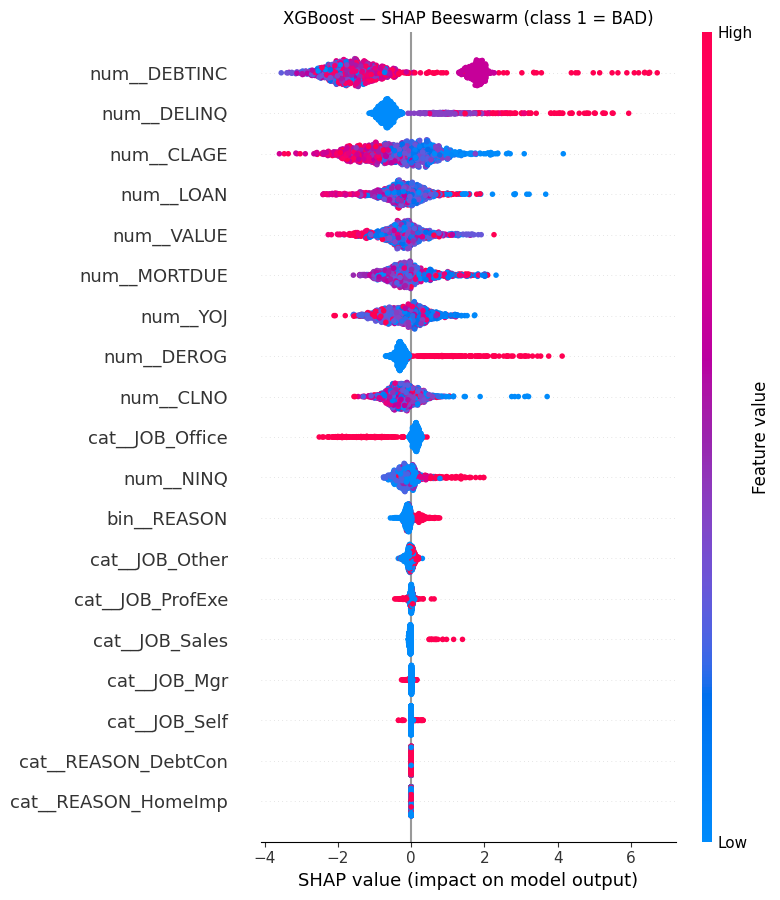

In [84]:
# --- SHAP beeswarm plot for the XGBoost model (runs after your code) ---

# If needed:
# !pip install shap

import numpy as np
import shap
import matplotlib.pyplot as plt

# 1) Grab the fitted XGBoost pipeline
xgb_pipe  = best_models["XGBoost"]
preproc   = xgb_pipe.named_steps["preproc"]
xgb_model = xgb_pipe.named_steps["model"]

# 2) Transform X_test and get feature names
def _feature_names_from_ct(ct):
    try:
        return ct.get_feature_names_out()
    except Exception:
        names = []
        for name, trans, cols in ct.transformers_:
            if trans == 'drop':
                continue
            if hasattr(trans, "named_steps") and "onehot" in trans.named_steps:
                ohe = trans.named_steps["onehot"]
                try:
                    out = ohe.get_feature_names_out(cols)
                except Exception:
                    out = ohe.get_feature_names(cols)
                names.extend(out.tolist())
            else:
                names.extend(list(cols))
        return np.array(names, dtype=object)

X_test_trans = preproc.transform(X_test)
feature_names = _feature_names_from_ct(preproc)

# Convert to dense if sparse
try:
    X_test_trans = X_test_trans.toarray()
except Exception:
    pass

# (Optional) subsample for speed if very large:
n = X_test_trans.shape[0]
if n > 5000:
    rng = np.random.default_rng(42)
    idx_sample = rng.choice(n, size=5000, replace=False)
    X_for_shap = X_test_trans[idx_sample]
else:
    X_for_shap = X_test_trans

# 3) TreeExplainer and SHAP values for class 1 (BAD)
explainer = shap.TreeExplainer(xgb_model)
shap_vals = explainer.shap_values(X_for_shap)

# Handle SHAP versions that return list per class
if isinstance(shap_vals, list):
    shap_vals_pos = shap_vals[1]  # class "1" = BAD
else:
    shap_vals_pos = shap_vals

# 4) Beeswarm (summary) plot
plt.figure(figsize=(4, 4))
shap.summary_plot(
    shap_vals_pos,
    X_for_shap,
    feature_names=feature_names,
    plot_type="dot",
    show=False,
    max_display=20
)
plt.title("XGBoost — SHAP Beeswarm (class 1 = BAD)")
plt.tight_layout()
plt.show()
